In [ ]:
import pennylane as qml
from pennylane.optimize import AdamOptimizer, GradientDescentOptimizer
import matplotlib.pyplot as plt
import math
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import argparse

from scipy import misc
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import os
from sklearn.decomposition import PCA
import numpy as np
import torchvision
import matplotlib.pyplot as plt
from skimage import io
import torchvision.datasets.mnist as mnist
from PIL import Image

import os, math, numpy as np
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.decomposition import PCA
import torchvision
from torchvision import transforms
from torchvision.datasets import mnist  # for raw IDX readers
from torch.optim.lr_scheduler import CosineAnnealingLR


C:\Users\maya\AppData\Local\Temp\ipykernel_30672\3341949382.py:13: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


epoch 1 | step 500/60000 | loss 0.1300
epoch 1 | step 1000/60000 | loss 0.0377
epoch 1 | step 1500/60000 | loss 0.0294
epoch 1 | step 2000/60000 | loss 0.0240
epoch 1 | step 2500/60000 | loss 0.0190
epoch 1 | step 3000/60000 | loss 0.0142
epoch 1 | step 3500/60000 | loss 0.0126
epoch 1 | step 4000/60000 | loss 0.0122
epoch 1 | step 4500/60000 | loss 0.0118
epoch 1 | step 5000/60000 | loss 0.0119
epoch 1 | step 5500/60000 | loss 0.0114
epoch 1 | step 6000/60000 | loss 0.0121
epoch 1 | step 6500/60000 | loss 0.0108
epoch 1 | step 7000/60000 | loss 0.0109
epoch 1 | step 7500/60000 | loss 0.0116
epoch 1 | step 8000/60000 | loss 0.0109
epoch 1 | step 8500/60000 | loss 0.0121
epoch 1 | step 9000/60000 | loss 0.0113
epoch 1 | step 9500/60000 | loss 0.0108
epoch 1 | step 10000/60000 | loss 0.0110
epoch 1 | step 10500/60000 | loss 0.0117
epoch 1 | step 11000/60000 | loss 0.0115
epoch 1 | step 11500/60000 | loss 0.0108
epoch 1 | step 12000/60000 | loss 0.0106
epoch 1 | step 12500/60000 | loss 0.

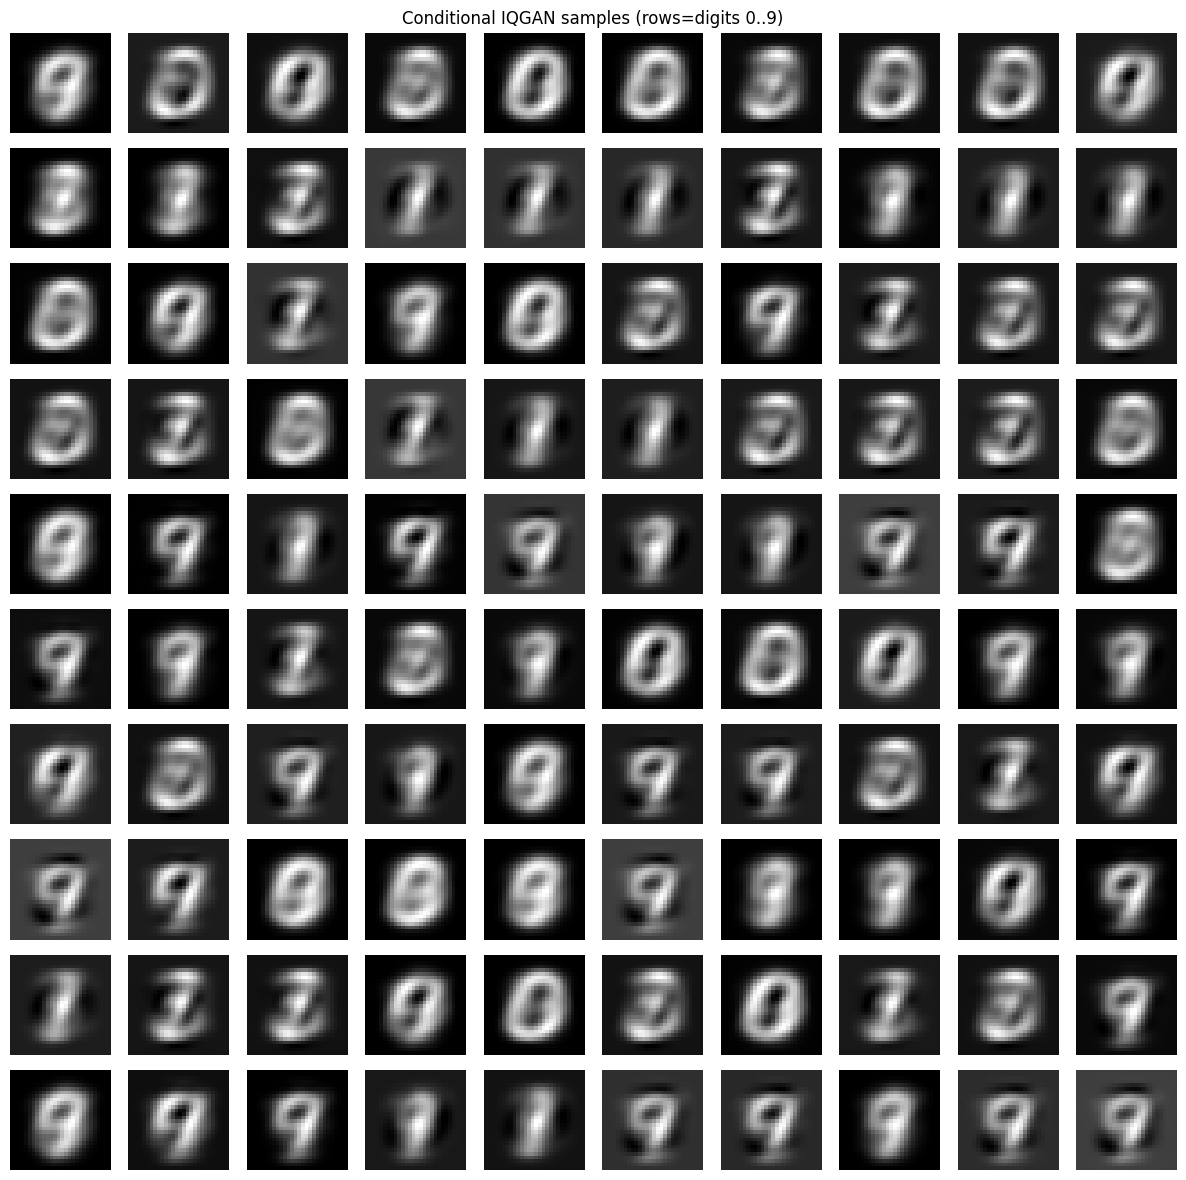

In [ ]:
BATCH_SIZE = 32            # unused (looping like your code), keep for symmetry
epochs     = 3             # try 10+ for better results
lr         = 1e-3
w_decay    = 1e-4
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SAVE_PATH  = "./cond_iqgan.pth"   # weights of the swap-test model
GEN_PATH   = "./cond_iqgan_gen.pth"  # optional separate save (same params)

def load_all_digits(download=True):
    if not (os.path.exists("./dataset/")) or not os.listdir("./dataset/"):
        download = True
    _ = torchvision.datasets.MNIST(
        root="./dataset/", train=True, transform=transforms.ToTensor(), download=download
    )

    root = "./dataset/MNIST/raw"
    imgs  = mnist.read_image_file(os.path.join(root, 'train-images-idx3-ubyte')).numpy() / 255.0
    labels= mnist.read_label_file(os.path.join(root, 'train-labels-idx1-ubyte')).numpy()
    imgs  = imgs.reshape(imgs.shape[0], 28*28)  # [N, 784]
    return imgs.astype(np.float32), labels.astype(np.int64)

data, labels = load_all_digits()

k = 2
pca = PCA(n_components=k).fit(data)
pca_data = pca.transform(data)                   # [N,2]
pca_descaler = [[] for _ in range(k)]
pca_data_scaled = pca_data.copy()
for i in range(k):
    if pca_data_scaled[:,i].min() < 0:
        pca_descaler[i].append(pca_data_scaled[:,i].min())
        pca_data_scaled[:,i] += abs(pca_data_scaled[:,i].min())
    else:
        pca_descaler[i].append(pca_data_scaled[:,i].min())
        pca_data_scaled[:,i] -= pca_data_scaled[:,i].min()
    pca_descaler[i].append(pca_data_scaled[:,i].max())
    pca_data_scaled[:,i] /= max(pca_data_scaled[:,i].max(), 1e-8)

# arcsin(sqrt(x)) (IQ style) for the REAL side only
pca_data_rot = np.arcsin(np.sqrt(np.clip(pca_data_scaled, 1e-8, 1-1e-8)))  # [N,2], in [0, π/2]

# utility to invert PCA scaling (expects features in [0,1])
def descale_points(d_point, scales=pca_descaler, tfrm=pca):
    d_point = d_point.copy()
    for col in range(d_point.shape[1]):
        d_point[:,col] *= scales[col][1]
        d_point[:,col] += scales[col][0]
    return tfrm.inverse_transform(d_point)  # → [*, 784]

class CondOffset(nn.Module):
    """Map a one-hot label (10,) to two small angle offsets added to noise angles."""
    def __init__(self, n_classes=10, out_dim=2, scale=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_classes, 16), nn.ReLU(inplace=True),
            nn.Linear(16, out_dim)
        )
        self.scale = scale
        self.tanh  = nn.Tanh()
    def forward(self, y_onehot):         # [10] or [B,10]
        return self.scale * self.tanh(self.net(y_onehot))

cond_map = CondOffset().to(device)

# wires: ancilla(0), fake(1,2), real(3,4)
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnode_swap(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):
    # inputs = [z0_cond, z1_cond, real0_rot, real1_rot]
    qml.RY(inputs[0], wires=1)
    qml.RY(inputs[1], wires=2)

    qml.RY(inputs[2], wires=3)
    qml.RY(inputs[3], wires=4)

    # VQC on fake (your original structure)
    qml.RX(w000, wires=1); qml.RX(w001, wires=2)
    qml.RY(w008, wires=1); qml.RY(w009, wires=2)
    qml.RZ(w016, wires=1); qml.RZ(w017, wires=2)
    qml.CNOT(wires=[1,2]); qml.CNOT(wires=[2,1])

    qml.RX(w200, wires=1); qml.RX(w201, wires=2)
    qml.RY(w208, wires=1); qml.RY(w209, wires=2)
    qml.RZ(w216, wires=1); qml.RZ(w217, wires=2)
    qml.CNOT(wires=[1,2]); qml.CNOT(wires=[2,1])

    # swap test between fake(1,2) and real(3,4)
    qml.Hadamard(0)
    qml.CSWAP(wires=[0, 1, 3])
    qml.CSWAP(wires=[0, 2, 4])
    qml.Hadamard(0)
    return qml.probs(wires=[0])   # [p0, p1]

weight_shapes = {k: 1 for k in
    ["w000","w001","w008","w009","w016","w017","w200","w201","w208","w209","w216","w217"]}

class CondIQGANSwap(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_swap, weight_shapes)
    def forward(self, x):  # x: [4] = [z0c, z1c, r0, r1]
        return self.qlayer(x)

model = CondIQGANSwap().to(device)

class Logloss(nn.Module):
    def forward(self, probs):   # probs: [2] with probs[0] = P(anc=0)
        # maximize P(anc=0) => minimize -log(probs[0])
        return torch.mean(-torch.log(torch.clamp(probs[0], 1e-6, 1.0)))

optimizer = optim.Adam(list(model.parameters()) + list(cond_map.parameters()),
                       lr=lr, weight_decay=w_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=30)
criterion = Logloss()

def onehot(y, n=10):
    v = torch.zeros(n, dtype=torch.float32, device=device)
    v[y] = 1.0
    return v

def train_epoch(epoch):
    model.train(); cond_map.train()
    running = 0.0
    N = pca_data_rot.shape[0]
    order = np.random.permutation(N)
    for i, idx in enumerate(order):
        # label and real features
        y = int(labels[idx])
        y1h = onehot(y)                   # [10]
        real_rot = torch.tensor(pca_data_rot[idx], dtype=torch.float32, device=device)  # [2]

        # noise + conditional shift
        z = torch.empty(2, dtype=torch.float32, device=device).uniform_(0.3, 0.9)       # [2]
        z = z + cond_map(y1h)   # add small label-dependent offsets
        z = torch.clamp(z, 0.0, math.pi/2)  # keep angles reasonable

        # qnode input: [z0c, z1c, real0_rot, real1_rot]
        qin = torch.cat([z, real_rot], dim=0)

        optimizer.zero_grad()
        probs = model(qin)                # [2]
        loss  = criterion(probs)
        loss.backward()
        optimizer.step()

        running += loss.item()
        if (i+1) % 500 == 0:
            print(f"epoch {epoch} | step {i+1}/{N} | loss {running/500:.4f}")
            running = 0.0
    scheduler.step()

for ep in range(1, epochs+1):
    train_epoch(ep)

# save
torch.save({"swap": model.state_dict(), "cond": cond_map.state_dict()}, SAVE_PATH)
print("Saved:", SAVE_PATH)

gen_dev = qml.device("default.qubit", wires=2)

@qml.qnode(gen_dev, interface="torch")
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):
    # inputs: [z0c, z1c]
    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    qml.RX(w000, wires=0); qml.RX(w001, wires=1)
    qml.RY(w008, wires=0); qml.RY(w009, wires=1)
    qml.RZ(w016, wires=0); qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1]); qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0); qml.RX(w201, wires=1)
    qml.RY(w208, wires=0); qml.RY(w209, wires=1)
    qml.RZ(w216, wires=0); qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1]); qml.CNOT(wires=[1,0])

    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

gen_weight_shapes = weight_shapes.copy()

class CondGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, gen_weight_shapes)
    def forward(self, z):   # z: [2] angles
        return self.qlayer(z)

G = CondGenerator().to(device)
state = torch.load(SAVE_PATH, map_location=device)
G.load_state_dict(state["swap"])
cond_map.load_state_dict(state["cond"])  # re-use trained conditional offsets

torch.save({"G": G.state_dict(), "cond": cond_map.state_dict()}, GEN_PATH)

@torch.no_grad()
def sample_conditional(label, n=16):
    G.eval(); cond_map.eval()
    y1h = onehot(label)
    feats = []
    for _ in range(n):
        z = torch.empty(2, dtype=torch.float32, device=device).uniform_(0.3, 0.9)
        zc = torch.clamp(z + cond_map(y1h), 0.0, math.pi/2)
        out = G(zc)                  # shape [2] in [-1,1]
        out = out * out              #  original square → [0,1]
        feats.append(out.unsqueeze(0))
    feats = torch.cat(feats, dim=0).cpu().numpy()  # [n,2] in [0,1]
    # invert PCA back to images
    recon = descale_points(feats)                  # [n,784]
    imgs  = recon.reshape(n, 28, 28)
    return feats, imgs

n_each = 10
all_imgs = []
for d in range(10):
    _, imgs = sample_conditional(d, n=n_each)
    all_imgs.append(imgs)
all_imgs = np.concatenate(all_imgs, axis=0)  # [10*n_each, 28,28]

rows, cols = 10, n_each
plt.figure(figsize=(1.2*cols, 1.2*rows))
for i in range(rows*cols):
    plt.subplot(rows, cols, i+1)
    plt.imshow(all_imgs[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Conditional IQGAN samples (rows=digits 0..9)")
plt.tight_layout()
plt.savefig("cond_iqgan_grid.png", dpi=150)
plt.show()


In [12]:
BATCH_SIZE = 32
epochs = 1
lr = 1e-3
w_decay = 1e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def data_prepare(data_label, DOWNLOAD_MNIST=True):
    # Mnist digits dataset
    if not (os.path.exists("./dataset/")) or not os.listdir("./dataset/"):
        DOWNLOAD_MNIST = True

    train_data = torchvision.datasets.MNIST(
        root="./dataset/",
        train=True,  # this is training data
        transform=torchvision.transforms.ToTensor(),  # Converts a PIL.Image or numpy.ndarray to
        download=DOWNLOAD_MNIST)

    root = "./dataset/MNIST/raw"
    train_set = (
        mnist.read_image_file(os.path.join(root, 'train-images-idx3-ubyte')),
        mnist.read_label_file(os.path.join(root, 'train-labels-idx1-ubyte')))

    data = []
    for i, (img, label) in enumerate(zip(train_set[0], train_set[1])):
        if label == data_label:
            data.append(img.numpy()/255)
    return data


data = np.array(data_prepare(data_label=5))
data = data.reshape(data.shape[0], data.shape[1]*data.shape[2])

# --------------------------------------------------
# ---------------- PCA Section ---------------------
# --------------------------------------------------
k=2
pca = PCA(n_components=k) # k represents the number of return
pca.fit(data)
pca_data = pca.transform(data)
t_pca_data = pca_data.copy()
pca_descaler = [[] for _ in range(k)]

for i in range(k):
    if pca_data[:,i].min() < 0:
        pca_descaler[i].append(pca_data[:,i].min())
        pca_data[:,i] += np.abs(pca_data[:,i].min())
    else:
        pca_descaler[i].append(pca_data[:,i].min())
        pca_data[:,i] -= pca_data[:,i].min()
    pca_descaler[i].append(pca_data[:,i].max())
    pca_data[:,i] /= pca_data[:,i].max()



pca_data_rot= np.arcsin(np.sqrt(pca_data))
# --------------------------------------------------
# Define a function that can take in PCA'ed data and return an image
# --------------------------------------------------
def descale_points(d_point,scales=pca_descaler,tfrm=pca):
    for col in range(d_point.shape[1]):
        d_point[:,col] *= scales[col][1]
        d_point[:,col] += scales[col][0]
    # print("dasdasdasdasd", d_point)
    reconstruction = tfrm.inverse_transform(d_point)
    return reconstruction
# --------------------------------------------------------------------------------------------------------------------------------------------------------------

n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):


    qml.RY(inputs[0], wires=1)
    qml.RY(inputs[1], wires=2)

    qml.RY(inputs[2], wires=3)
    qml.RY(inputs[3], wires=4)

    qml.RX(w000, wires=1)
    qml.RX(w001, wires=2)

    qml.RY(w008, wires=1)
    qml.RY(w009, wires=2)

    qml.RZ(w016, wires=1)
    qml.RZ(w017, wires=2)
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,1])

    qml.RX(w200, wires=1)
    qml.RX(w201, wires=2)

    qml.RY(w208, wires=1)
    qml.RY(w209, wires=2)

    qml.RZ(w216, wires=1)
    qml.RZ(w217, wires=2)
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,1])

    # swap test
    qml.Hadamard(0)
    qml.CSWAP(wires=[0, 1, 3])
    qml.CSWAP(wires=[0, 2, 4])
    qml.Hadamard(0)

    return qml.probs(wires=[0])

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model = MNIST().to(device)
# ----------------------------------------------------------------training function-----------------------------------------------------------------------------
class Logloss(nn.Module):
    def __init__(self):
        super(Logloss, self).__init__()
    def forward(self, output):
        return torch.mean(-torch.log(output[0]))

def train(model, device, optimizer, epoch):
    data = []
    running_loss = 0.0
    output_sum = 0.0
    loss_sum = 0.0
    for i in range(len(pca_data)):
        noise = torch.empty(2, dtype=torch.float32).uniform_(0.3,0.9).to(device)
        inputs = torch.Tensor(pca_data_rot[i]).to(device)
        inputs = torch.cat((noise, inputs), 0)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss_function = Logloss()
        loss = loss_function(outputs)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        running_loss += loss.item()
        output_sum += outputs
        if (i+1) % 100 == 0:
            print('epoch: %d, loss: %.3f' % (epoch, running_loss / 100))
            running_loss = 0.0
    this_epoch_loss = loss_sum/len(pca_data)
    this_epoch_output = output_sum/len(pca_data)
    return this_epoch_loss, this_epoch_output

# --------------------------------------------------------------------------------------------------------------------------------------------------------------
# ------------------------------------------------------------------------main----------------------------------------------------------------------------------
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = CosineAnnealingLR(optimizer, T_max=30)
highest_acc = 0
loss_list = []
output_list = []
test_output = []
for epoch in range(epochs):
    a, b = train(model, device, optimizer, epoch)
    loss_list.append(a)
    output_list.append(b)
    torch.save(model.state_dict(), './2gan_1.pth')
    # torch.save(model.state_dict(), './hh.pth')
    print("loss list is:", loss_list)
    print("output list is:",output_list)



epoch: 0, loss: 0.360
epoch: 0, loss: 0.261
epoch: 0, loss: 0.203
epoch: 0, loss: 0.149
epoch: 0, loss: 0.110
epoch: 0, loss: 0.081
epoch: 0, loss: 0.056
epoch: 0, loss: 0.045
epoch: 0, loss: 0.034
epoch: 0, loss: 0.033
epoch: 0, loss: 0.024
epoch: 0, loss: 0.026
epoch: 0, loss: 0.027
epoch: 0, loss: 0.020
epoch: 0, loss: 0.023
epoch: 0, loss: 0.021
epoch: 0, loss: 0.021
epoch: 0, loss: 0.025
epoch: 0, loss: 0.021
epoch: 0, loss: 0.022
epoch: 0, loss: 0.026
epoch: 0, loss: 0.021
epoch: 0, loss: 0.022
epoch: 0, loss: 0.018
epoch: 0, loss: 0.019
epoch: 0, loss: 0.024
epoch: 0, loss: 0.019
epoch: 0, loss: 0.020
epoch: 0, loss: 0.019
epoch: 0, loss: 0.024
epoch: 0, loss: 0.023
epoch: 0, loss: 0.022
epoch: 0, loss: 0.023
epoch: 0, loss: 0.024
epoch: 0, loss: 0.023
epoch: 0, loss: 0.022
epoch: 0, loss: 0.021
epoch: 0, loss: 0.024
epoch: 0, loss: 0.022
epoch: 0, loss: 0.022
epoch: 0, loss: 0.019
epoch: 0, loss: 0.019
epoch: 0, loss: 0.023
epoch: 0, loss: 0.024
epoch: 0, loss: 0.023
epoch: 0, 

Epoch 0 Generated Images


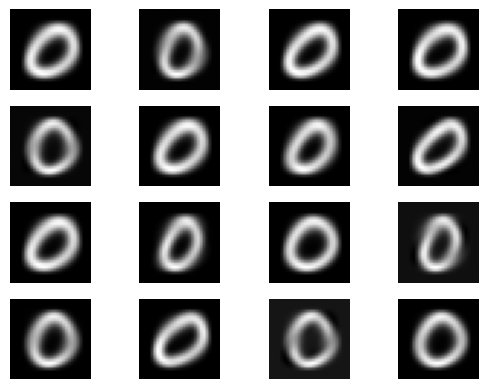

In [3]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # generating fake feature map
    qml.RX(w000, wires=0)
    qml.RX(w001, wires=1)

    qml.RY(w008, wires=0)
    qml.RY(w009, wires=1)

    qml.RZ(w016, wires=0)
    qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0)
    qml.RX(w201, wires=1)

    qml.RY(w208, wires=0)
    qml.RY(w209, wires=1)

    qml.RZ(w216, wires=0)
    qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])


    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST_GEN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model_gen = MNIST_GEN().to(device)

model_gen.load_state_dict(torch.load('./2gan_1.pth'))

def test(model, device):
    inputs = torch.empty((16, 2), dtype=torch.float32).uniform_(0.3,0.9)

    outputs = torch.rand((16, 2), device=device)
    for i in range(16):
        outputs[i] = model(inputs[i])*model(inputs[i])
    return outputs


output = test(model_gen, device).detach().numpy()
output = descale_points(output)




new_info = output.reshape(output.shape[0],28,28)
print(f"Epoch {epoch} Generated Images")
for i in range(new_info.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(new_info[i, :, :], cmap='gray')
    plt.axis('off')
plt.savefig("qgan_-epoch-mnist-{}-generated-images".format(epoch))
plt.show()

Epoch 0 Generated Images


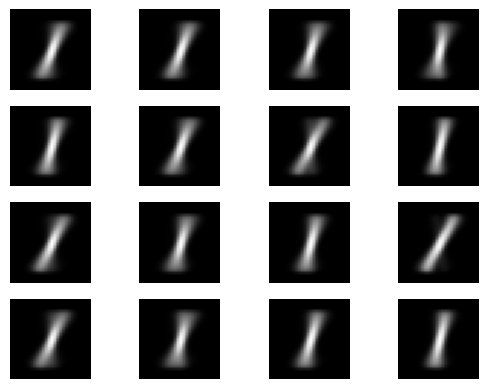

In [5]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # generating fake feature map
    qml.RX(w000, wires=0)
    qml.RX(w001, wires=1)

    qml.RY(w008, wires=0)
    qml.RY(w009, wires=1)

    qml.RZ(w016, wires=0)
    qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0)
    qml.RX(w201, wires=1)

    qml.RY(w208, wires=0)
    qml.RY(w209, wires=1)

    qml.RZ(w216, wires=0)
    qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])


    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST_GEN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model_gen = MNIST_GEN().to(device)

model_gen.load_state_dict(torch.load('./2gan_1.pth'))

def test(model, device):
    inputs = torch.empty((16, 2), dtype=torch.float32).uniform_(0.3,0.9)

    outputs = torch.rand((16, 2), device=device)
    for i in range(16):
        outputs[i] = model(inputs[i])*model(inputs[i])
    return outputs


output = test(model_gen, device).detach().numpy()
output = descale_points(output)




new_info = output.reshape(output.shape[0],28,28)
print(f"Epoch {epoch} Generated Images")
for i in range(new_info.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(new_info[i, :, :], cmap='gray')
    plt.axis('off')
plt.savefig("qgan_-epoch-mnist-{}-generated-images".format(epoch))
plt.show()

Epoch 0 Generated Images


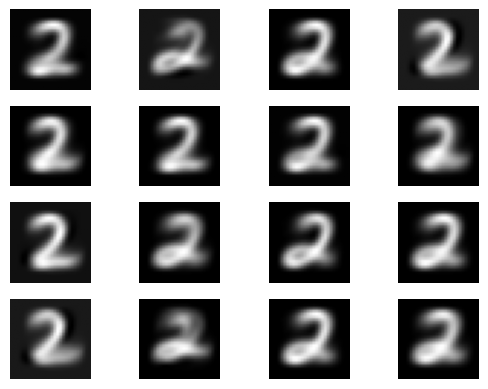

In [7]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # generating fake feature map
    qml.RX(w000, wires=0)
    qml.RX(w001, wires=1)

    qml.RY(w008, wires=0)
    qml.RY(w009, wires=1)

    qml.RZ(w016, wires=0)
    qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0)
    qml.RX(w201, wires=1)

    qml.RY(w208, wires=0)
    qml.RY(w209, wires=1)

    qml.RZ(w216, wires=0)
    qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])


    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST_GEN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model_gen = MNIST_GEN().to(device)

model_gen.load_state_dict(torch.load('./2gan_1.pth'))

def test(model, device):
    inputs = torch.empty((16, 2), dtype=torch.float32).uniform_(0.3,0.9)

    outputs = torch.rand((16, 2), device=device)
    for i in range(16):
        outputs[i] = model(inputs[i])*model(inputs[i])
    return outputs


output = test(model_gen, device).detach().numpy()
output = descale_points(output)




new_info = output.reshape(output.shape[0],28,28)
print(f"Epoch {epoch} Generated Images")
for i in range(new_info.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(new_info[i, :, :], cmap='gray')
    plt.axis('off')
plt.savefig("qgan_-epoch-mnist-{}-generated-images".format(epoch))
plt.show()

Epoch 0 Generated Images


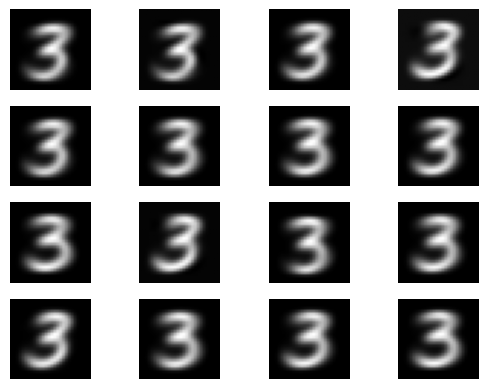

In [9]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # generating fake feature map
    qml.RX(w000, wires=0)
    qml.RX(w001, wires=1)

    qml.RY(w008, wires=0)
    qml.RY(w009, wires=1)

    qml.RZ(w016, wires=0)
    qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0)
    qml.RX(w201, wires=1)

    qml.RY(w208, wires=0)
    qml.RY(w209, wires=1)

    qml.RZ(w216, wires=0)
    qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])


    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST_GEN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model_gen = MNIST_GEN().to(device)

model_gen.load_state_dict(torch.load('./2gan_1.pth'))

def test(model, device):
    inputs = torch.empty((16, 2), dtype=torch.float32).uniform_(0.3,0.9)

    outputs = torch.rand((16, 2), device=device)
    for i in range(16):
        outputs[i] = model(inputs[i])*model(inputs[i])
    return outputs


output = test(model_gen, device).detach().numpy()
output = descale_points(output)




new_info = output.reshape(output.shape[0],28,28)
print(f"Epoch {epoch} Generated Images")
for i in range(new_info.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(new_info[i, :, :], cmap='gray')
    plt.axis('off')
plt.savefig("qgan_-epoch-mnist-{}-generated-images".format(epoch))
plt.show()

Epoch 0 Generated Images


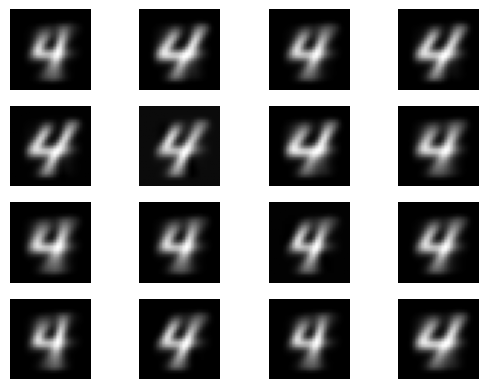

In [11]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # generating fake feature map
    qml.RX(w000, wires=0)
    qml.RX(w001, wires=1)

    qml.RY(w008, wires=0)
    qml.RY(w009, wires=1)

    qml.RZ(w016, wires=0)
    qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0)
    qml.RX(w201, wires=1)

    qml.RY(w208, wires=0)
    qml.RY(w209, wires=1)

    qml.RZ(w216, wires=0)
    qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])


    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST_GEN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model_gen = MNIST_GEN().to(device)

model_gen.load_state_dict(torch.load('./2gan_1.pth'))

def test(model, device):
    inputs = torch.empty((16, 2), dtype=torch.float32).uniform_(0.3,0.9)

    outputs = torch.rand((16, 2), device=device)
    for i in range(16):
        outputs[i] = model(inputs[i])*model(inputs[i])
    return outputs


output = test(model_gen, device).detach().numpy()
output = descale_points(output)




new_info = output.reshape(output.shape[0],28,28)
print(f"Epoch {epoch} Generated Images")
for i in range(new_info.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(new_info[i, :, :], cmap='gray')
    plt.axis('off')
plt.savefig("qgan_-epoch-mnist-{}-generated-images".format(epoch))
plt.show()

Epoch 0 Generated Images


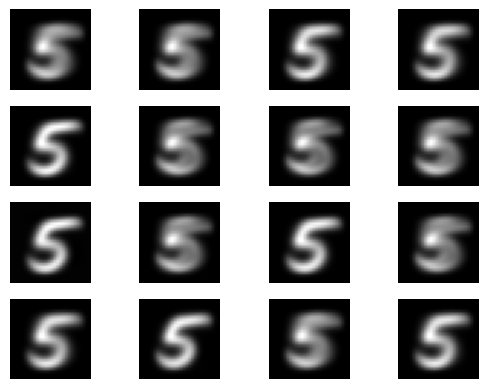

In [13]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # generating fake feature map
    qml.RX(w000, wires=0)
    qml.RX(w001, wires=1)

    qml.RY(w008, wires=0)
    qml.RY(w009, wires=1)

    qml.RZ(w016, wires=0)
    qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0)
    qml.RX(w201, wires=1)

    qml.RY(w208, wires=0)
    qml.RY(w209, wires=1)

    qml.RZ(w216, wires=0)
    qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])


    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST_GEN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model_gen = MNIST_GEN().to(device)

model_gen.load_state_dict(torch.load('./2gan_1.pth'))

def test(model, device):
    inputs = torch.empty((16, 2), dtype=torch.float32).uniform_(0.3,0.9)

    outputs = torch.rand((16, 2), device=device)
    for i in range(16):
        outputs[i] = model(inputs[i])*model(inputs[i])
    return outputs


output = test(model_gen, device).detach().numpy()
output = descale_points(output)




new_info = output.reshape(output.shape[0],28,28)
print(f"Epoch {epoch} Generated Images")
for i in range(new_info.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(new_info[i, :, :], cmap='gray')
    plt.axis('off')
plt.savefig("qgan_-epoch-mnist-{}-generated-images".format(epoch))
plt.show()

Epoch 0 Generated Images


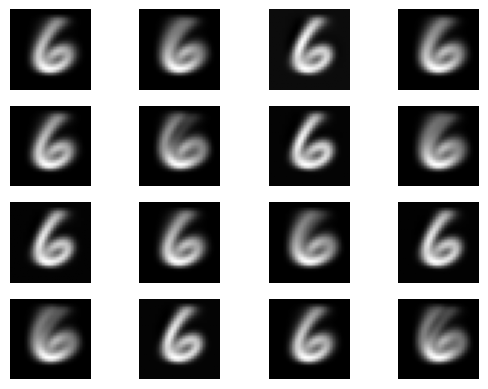

In [15]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def qnode_gen(inputs, w000, w001, w008, w009, w016, w017, w200, w201, w208, w209, w216, w217):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # generating fake feature map
    qml.RX(w000, wires=0)
    qml.RX(w001, wires=1)

    qml.RY(w008, wires=0)
    qml.RY(w009, wires=1)

    qml.RZ(w016, wires=0)
    qml.RZ(w017, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])

    qml.RX(w200, wires=0)
    qml.RX(w201, wires=1)

    qml.RY(w208, wires=0)
    qml.RY(w209, wires=1)

    qml.RZ(w216, wires=0)
    qml.RZ(w217, wires=1)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,0])


    return [qml.expval(qml.PauliX(0)), qml.expval(qml.PauliX(1))]

weight_shapes = {"w000": 1, "w001": 1, "w008": 1, "w009": 1, "w016": 1, "w017": 1, "w200": 1, "w201": 1, "w208": 1, "w209": 1, "w216": 1, "w217": 1}

# ----------------------------------------------------------------------model-----------------------------------------------------------------------------------
class MNIST_GEN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode_gen, weight_shapes)

    def forward(self, x):
        out = self.qlayer(x)
        return out

model_gen = MNIST_GEN().to(device)

model_gen.load_state_dict(torch.load('./2gan_1.pth'))

def test(model, device):
    inputs = torch.empty((16, 2), dtype=torch.float32).uniform_(0.3,0.9)

    outputs = torch.rand((16, 2), device=device)
    for i in range(16):
        outputs[i] = model(inputs[i])*model(inputs[i])
    return outputs


output = test(model_gen, device).detach().numpy()
output = descale_points(output)




new_info = output.reshape(output.shape[0],28,28)
print(f"Epoch {epoch} Generated Images")
for i in range(new_info.shape[0]):
    plt.subplot(4, 4, i+1)
    plt.imshow(new_info[i, :, :], cmap='gray')
    plt.axis('off')
plt.savefig("qgan_-epoch-mnist-{}-generated-images".format(epoch))
plt.show()